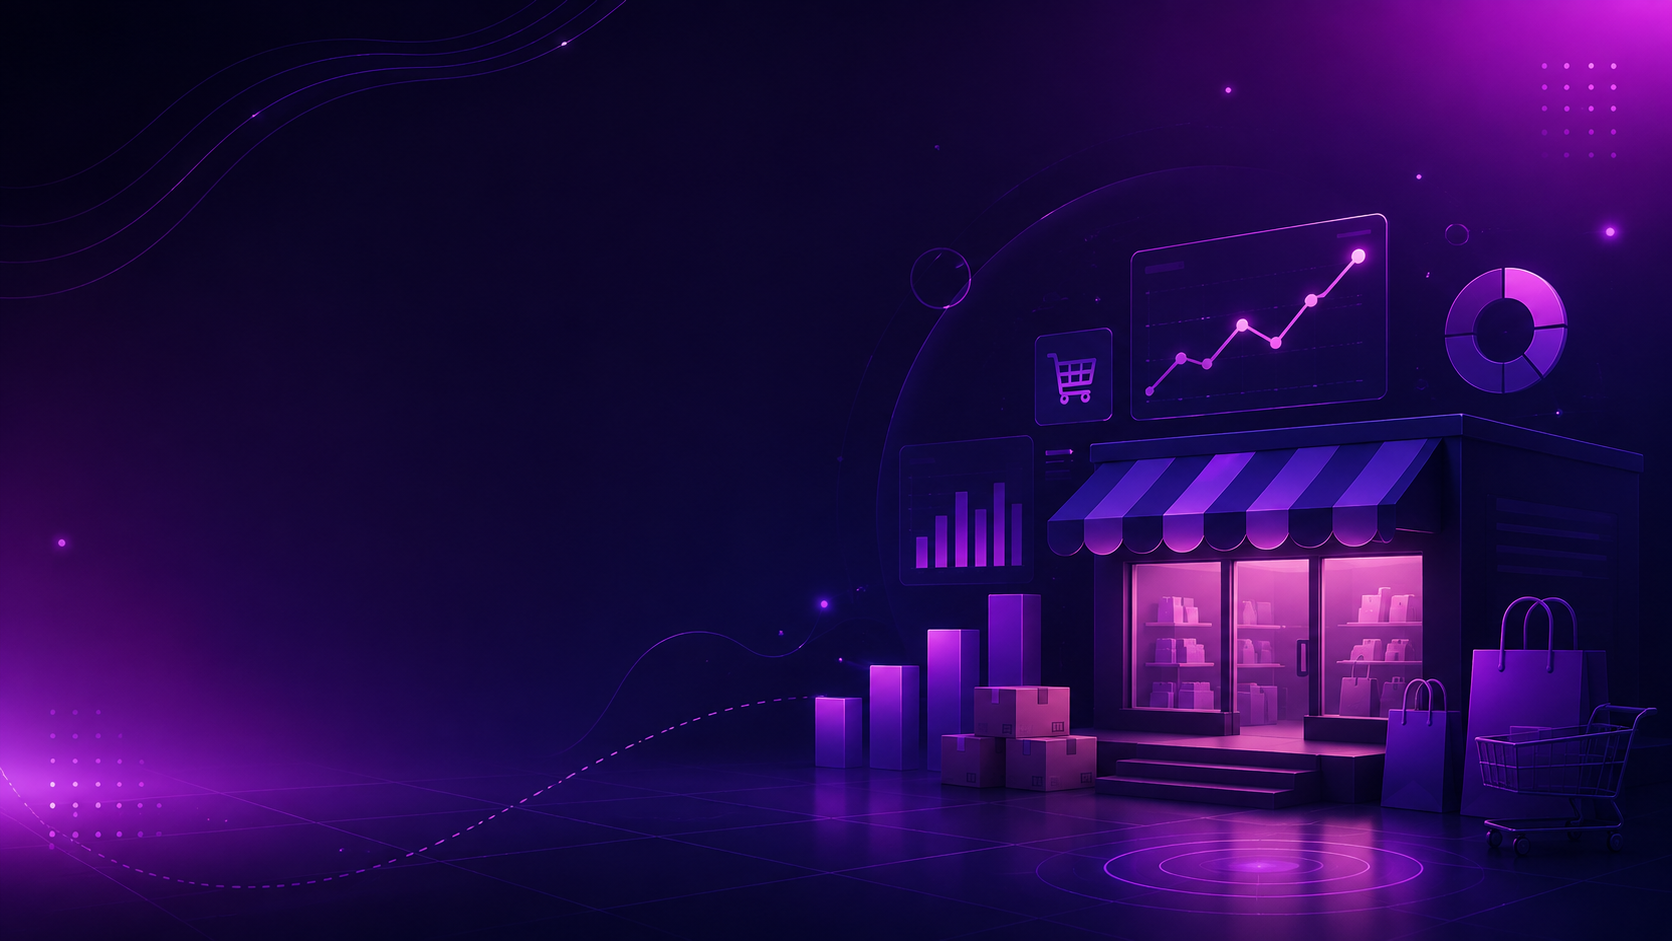

In [1]:
from IPython.display import Image, display

display(Image(
   "/kaggle/input/datasets/retagramyramdan/image-retail/retail.image.png" ,
    width=1200
))

<div style="
    background:
        radial-gradient(circle at 15% 20%, rgba(168,85,247,.30), transparent 30%),
        radial-gradient(circle at 85% 30%, rgba(236,72,153,.25), transparent 30%),
        linear-gradient(135deg, #080B1A, #11152B, #24103F);
    border: 1px solid rgba(168,85,247,.35);
    border-radius: 28px;
    padding: 45px 40px;
    margin: 10px 0 35px 0;
    box-shadow:
        0 0 25px rgba(168,85,247,.20),
        0 0 60px rgba(236,72,153,.10);
">

<div style="
    color:#A855F7;
    font-size:14px;
    font-weight:700;
    letter-spacing:4px;
    margin-bottom:12px;
">
RETAIL ANALYTICS • PYTHON PROJECT
</div>

<div style="
    color:#F8FAFC;
    font-size:42px;
    font-weight:800;
    margin-bottom:10px;
">
RETAIL SALES
<span style="color:#FF4FD8;">INTELLIGENCE</span>
</div>

<div style="
    color:#94A3B8;
    font-size:17px;
    line-height:1.6;
">
From raw transactions to customer intelligence,
profitability insights & predictive sales analysis.
</div>

<div style="
    margin-top:25px;
    color:#A855F7;
    font-size:13px;
    letter-spacing:2px;
">
PANDAS • PLOTLY • SEABORN • LINEAR REGRESSION
</div>

</div>


<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
    Import Libraries
</h2>


In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
import ipywidgets as widgets
from IPython.display import display
warnings.filterwarnings("ignore")
import plotly.io as pio
pio.renderers.default="notebook_connected"
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from IPython.display import display, HTML, Markdown

In [3]:
import plotly
import plotly.io as pio

print("Plotly version:", plotly.__version__)
print("Default renderer:", pio.renderers.default)
print("Available renderers:")
print(pio.renderers)

Plotly version: 5.24.1
Default renderer: notebook_connected
Available renderers:
Renderers configuration
-----------------------
    Default renderer: 'notebook_connected'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [4]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
     Read Data
</h2>


In [5]:
suppliers = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/supplier_data.csv")
orders = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/orders_data.csv")
products = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/products_data.csv")
promotions = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/promotion_data.csv")
brands = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/brand_data.csv")
order_items = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/order_items_data.csv")
returns = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/returns_data.csv")
employees = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/employee_data.csv")
customers = pd.read_csv("/kaggle/input/datasets/retagramyramdan/retail-sales-store/customer_data.csv")

<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
     Exploring Data
</h2>


In [6]:
promotions.head()

,promotion_id,promotion_name,promotion_type,discount_percent,minimum_order,start_date,end_date,coupon_code,usage_limit,status
0,1,Super Saver,Clearance,30,1579.41,2025-12-23,2026-08-05,SALE1,316,Active
1,2,Bundle Deal,Seasonal,21,585.25,2025-04-19,2026-08-05,SALE2,255,Active
2,3,Special Weekend,Seasonal,30,405.79,2025-09-27,2026-08-05,SALE3,210,Active
3,4,New Year Offer,Seasonal,7,1266.75,2024-11-10,2026-08-05,SALE4,242,Active
4,5,Winter Sale,Seasonal,6,1095.38,2026-03-28,2026-08-05,SALE5,228,Active


In [7]:
def dataset_summary(dataframe):
    row= []
    for name ,df in dataframe.items():
        row.append({
            "Dataset": name,
            "Rows": df.shape[0],
            "Columns": df.shape[1],
            "Missing Value": df.isna().sum().sum(),
            "Duplicates": df.duplicated().sum()
        })
    return pd.DataFrame(row)
datasets = {
    "Suppliers": suppliers,
    "Orders": orders,
    "Products": products,
    "Promotions": promotions,
    "Brands": brands,
    "Order Items": order_items,
    "Returns": returns,
    "Employees": employees,
    "Customers": customers
}
overview= dataset_summary(datasets)
overview

,Dataset,Rows,Columns,Missing Value,Duplicates
0,Suppliers,50,11,0,0
1,Orders,5000,10,955,0
2,Products,100,12,0,0
3,Promotions,30,10,0,0
4,Brands,20,8,0,0
5,Order Items,1500,5,0,0
6,Returns,1000,10,0,0
7,Employees,100,4,0,0
8,Customers,100,5,0,0


In [8]:
quality_report = []

for name, df in datasets.items():

    for column in df.columns:

        quality_report.append({
            "Dataset": name,
            "Column": column,
            "Data Type": str(df[column].dtype),
            "Missing": df[column].isna().sum(),
            "Missing %": round(df[column].isna().mean() * 100, 2),
            "Unique Values": df[column].nunique()
        })

quality_report = pd.DataFrame(quality_report)

quality_report.head(20)

,Dataset,Column,Data Type,Missing,Missing %,Unique Values
0,Suppliers,supplier_id,int64,0,0.0,50
1,Suppliers,supplier_name,object,0,0.0,50
2,Suppliers,contact_person,object,0,0.0,50
3,Suppliers,phone,int64,0,0.0,50
4,Suppliers,email,object,0,0.0,50
5,Suppliers,city,object,0,0.0,50
6,Suppliers,country,object,0,0.0,44
7,Suppliers,address,object,0,0.0,50
8,Suppliers,rating,float64,0,0.0,43
9,Suppliers,contract_start,object,0,0.0,50


In [9]:
quality_report[quality_report[ "Missing"]>0].sort_values( "Missing %",ascending=False)

,Dataset,Column,Data Type,Missing,Missing %,Unique Values
17,Orders,promotion_id,float64,955,19.1,30


In [10]:
date_columns = {
    "orders": ["order_date", "delivery_date"],
    "products": ["launch_date"],
    "promotions": ["start_date", "end_date"],
    "suppliers": ["contract_start"],
    "returns": ["return_date"],
    "customers": ["join_date"]
}
for dataset_name ,columns in date_columns.items():
    df= globals()[dataset_name]
    for column in columns:
        df[column]= pd.to_datetime( df[column],errors="coerce")

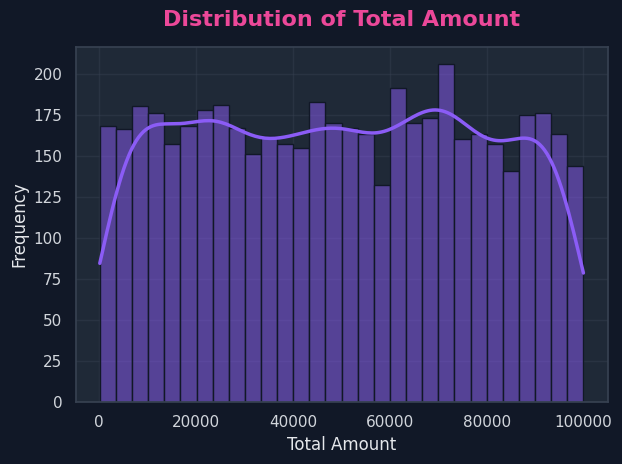

In [11]:
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "figure.facecolor": "#111827",
    "axes.facecolor": "#1F2937",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#E5E7EB",
    "xtick.color": "#D1D5DB",
    "ytick.color": "#D1D5DB",
    "text.color": "#E5E7EB",
    "grid.color": "#374151",
    "grid.alpha": 0.45
})

sns.histplot(
    data=orders,
    x="total_amount",
    bins=30,
    kde=True,
    color="#8B5CF6",
    edgecolor="#111827",
    line_kws={
        "color": "#EC4899",
        "linewidth": 2.5
    }
)

plt.title(
    "Distribution of Total Amount",
    fontsize=16,
    fontweight="bold",
    color="#EC4899",
    pad=15
)

plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
sales = (
    orders
    .merge(
        order_items,
        on="order_id",
        how="inner"
    )
    .merge(
        products,
        on="product_id",
        how="left"
    )
    .merge(
        brands,
        on="brand_id",
        how="left",
        suffixes=("", "_brand")
    )
    .merge(
        customers,
        on="customer_id",
        how="left",
        suffixes=("", "_customer")
    )
)
sales.shape
list(sales.columns)

['order_id',
 'customer_id',
 'employee_id',
 'payment_method',
 'total_amount',
 'order_date',
 'promotion_id',
 'delivery_status',
 'shipping_cost',
 'delivery_date',
 'order_item_id',
 'product_id',
 'quantity',
 'unit_price',
 'name',
 'category',
 'brand_id',
 'cost_price',
 'sell_price',
 'supplier_id',
 'stock_qty',
 'warranty_months',
 'weight',
 'color',
 'launch_date',
 'brand_name',
 'country',
 'founded_year',
 'website',
 'support_email',
 'phone',
 'status',
 'name_customer',
 'city',
 'join_date',
 'phone_customer']

In [13]:
sales["sales_amount"]= (sales["quantity"]*sales['unit_price'])
sales["cost_amount"] =(sales['quantity']-sales['cost_price'])
sales["profit"]=(sales["sales_amount"]-sales["cost_amount"])
sales["profit_margin"]=(sales["profit"]/sales["sales_amount"])*100

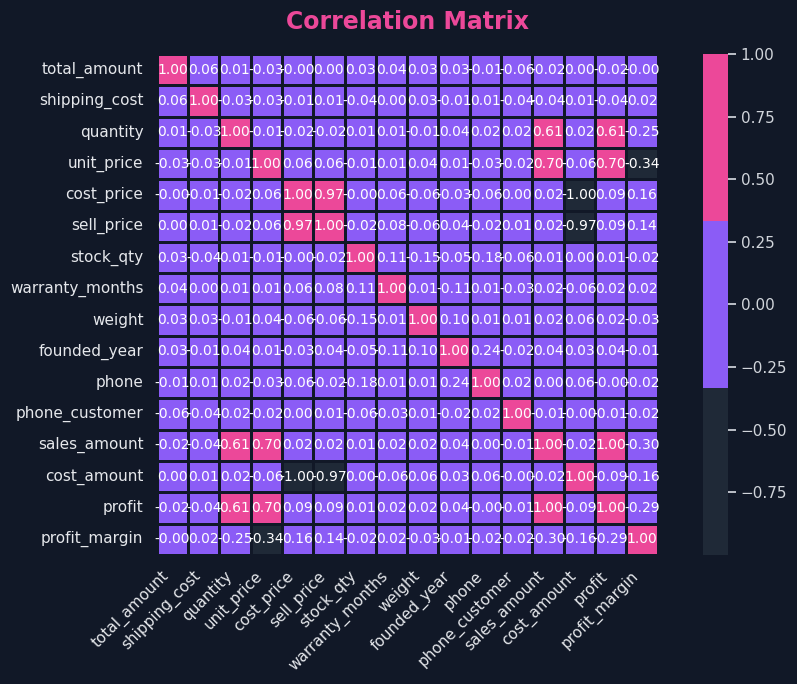

In [14]:
numercial_cols = sales.select_dtypes(include="number").columns
numercial_cols=[
    col for col in numercial_cols
    if "id" not in col.lower()
]
corr= sales[numercial_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        ["#1F2937", "#8B5CF6", "#EC4899"],
        as_cmap=True
    ),
    linewidths=0.8,
    linecolor="#111827",
    square=True,
    annot_kws={"fontsize": 10}
)

plt.title(
    "Correlation Matrix",
    fontsize=17,
    fontweight="bold",
    color="#EC4899",
    pad=18
)

plt.xticks(
    rotation=45,
    ha="right",
    color="#E5E7EB"
)

plt.yticks(
    rotation=0,
    color="#E5E7EB"
)

plt.tight_layout()
plt.show()

<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
    KPI
</h2>

In [15]:
total_revenue = sales["sales_amount"].sum()
total_profit = sales["profit"].sum()
total_units = sales["quantity"].sum()
total_orders = sales["order_id"].nunique()
total_customers = sales["customer_id"].nunique()

avg_order_value = (
    sales.groupby("order_id")["sales_amount"]
    .sum()
    .mean()
)

display(HTML(f"""
<div style="
display:flex;
gap:18px;
margin:25px 0;
flex-wrap:wrap;
">

{''.join([
f'''
<div style="
background:#11152B;
border:1px solid rgba(168,85,247,.35);
border-radius:20px;
padding:22px;
min-width:190px;
box-shadow:0 0 20px rgba(168,85,247,.10);
">
<div style="color:#94A3B8;font-size:13px;">{title}</div>
<div style="color:#F8FAFC;font-size:27px;font-weight:800;margin-top:7px;">
{value}
</div>
</div>
'''
for title, value in [
    ("TOTAL REVENUE", f"${total_revenue:,.0f}"),
    ("TOTAL PROFIT", f"${total_profit:,.0f}"),
    ("UNITS SOLD", f"{total_units:,.0f}"),
    ("ORDERS", f"{total_orders:,}"),
    ("CUSTOMERS", f"{total_customers:,}"),
    ("AVG ORDER VALUE", f"${avg_order_value:,.0f}")
]
])}

</div>
"""))

<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
    EDA
</h2>

In [16]:
category_sales = (
    sales
    .groupby("category")
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum"),
        Units=("quantity", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

fig = px.bar(
    category_sales,
    x="category",
    y="Revenue",
    color="Profit",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Revenue & Profit by Category"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Category",
    yaxis_title="Revenue",
    coloraxis_colorbar_title="Profit"
)

fig.show(renderer="iframe")

In [17]:
category_sales = (
    sales
    .groupby("category")
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum"),
        Units=("quantity", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

fig = px.bar(
    category_sales,
    x="category",
    y="Revenue",
    color="Units",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Revenue & Units by Category"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Category",
    yaxis_title="Revenue",
    coloraxis_colorbar_title="Profit"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Mobile Leads Category Performance
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
Mobile is the strongest-performing category across
<b style="color:#E8A0BF;">Revenue, Profit, and Units Sold</b>,
with Laptops ranking second.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
This indicates that <b style="color:white;">Mobile</b> is a key revenue and
profit contributor, making it a strong candidate for
<b style="color:#E8A0BF;">inventory prioritization, targeted promotions,
and customer-focused campaigns</b>.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
At the same time, Laptops represent the
<b style="color:white;">second-largest opportunity</b>, suggesting potential
for further growth through focused product and promotional strategies.
</p>

</div>

In [18]:
monthly_sales = (
    sales
    .groupby(
        sales["order_date"].dt.to_period("M")
    )
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum")
    )
    .reset_index()
)

monthly_sales["order_date"] = (
    monthly_sales["order_date"]
    .astype(str)
)

fig = px.area(
    monthly_sales,
    x="order_date",
    y="Revenue",
    title="Monthly Revenue Trend"
)

fig.update_traces(
    line=dict(
        color="#FF4FD8",
        width=3
    ),
    fillcolor="rgba(236,72,153,0.18)"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Month",
    yaxis_title="Revenue"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
January 2025 Shows a Revenue Peak
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
Revenue shows a noticeable upward trend, reaching a
<b style="color:#E8A0BF;">peak in January 2025</b>.
This month represents an important period of strong business performance
and deserves closer investigation.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
From a business perspective, identifying what drove this increase can help
support <b style="color:#E8A0BF;">better sales planning, inventory allocation,
and promotional decisions</b>.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
The next step is to investigate the underlying drivers by analyzing
<b style="color:white;">orders, promotions, products, and customer behavior</b>
to understand what contributed to the January performance.
</p>

</div>

In [19]:
product_profit = (
    sales
    .groupby(["product_id", "name"])
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum"),
        Units=("quantity", "sum")
    )
    .reset_index()
)

fig = px.scatter(
    product_profit,
    x="Revenue",
    y="Profit",
    size="Units",
    color="Profit",
    hover_name="name",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Product Revenue vs Profitability"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Revenue",
    yaxis_title="Profit"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Revenue and Profit Move Together
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
The analysis shows a <b style="color:#E8A0BF;">positive relationship</b>
between Revenue and Profit, meaning that higher revenue levels are generally
associated with higher profit.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
From a business perspective, this suggests that
<b style="color:#E8A0BF;">revenue growth is closely linked to profitability</b>,
making profitable sales growth an important priority for the business.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
The next step is to investigate which
<b style="color:white;">products, categories, and promotions</b>
contribute most to both revenue and profit.
</p>

</div>

In [20]:
top_products = (
    sales
    .groupby("name")
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
    .head(10)
    .sort_values("Revenue")
)

fig = px.bar(
    top_products,
    x="Revenue",
    y="name",
    orientation="h",
    color="Profit",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Top 10 Products by Revenue"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Revenue",
    yaxis_title="Product"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Wireless Mouse Leads Revenue & Profit
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
<b style="color:#E8A0BF;">Wireless Mouse</b> is the top-performing product
in both <b style="color:white;">Revenue and Profit</b>, making it a key
contributor to overall business performance.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
Its strong performance <b style="color:#E8A0BF;">may be a contributing factor</b>
to the overall revenue and profit levels, highlighting the importance of
understanding what drives its demand.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
Further analysis will examine its
<b style="color:white;">sales volume, pricing, promotions, and customer demand</b>
to identify the key factors behind this performance.
</p>

</div>

In [21]:
brand_sales = (
    sales
    .groupby("brand_name")
    .agg(
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum"),
        Units=("quantity", "sum")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

fig = px.bar(
    brand_sales,
    x="brand_name",
    y="Revenue",
    color="Profit",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Revenue by Brand"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Brand",
    yaxis_title="Revenue"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Acer Leads Brand Performance
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
<b style="color:#E8A0BF;">Acer</b> is the top-performing brand in both
<b style="color:white;">Revenue and Profit</b>, making it a key contributor
to the business's overall financial performance.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
This strong performance highlights Acer as a potential priority for
<b style="color:#E8A0BF;">inventory planning, product availability,
and targeted marketing strategies</b>.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
Further analysis can explore the
<b style="color:white;">products, customers, and promotions</b>
driving Acer's performance to identify opportunities for sustained growth.
</p>

</div>

In [22]:
customer_revenue = (
    sales
    .groupby("customer_id")
    .agg(
        Revenue=("sales_amount", "sum")
    )
    .reset_index()
)

fig = px.histogram(
    customer_revenue,
    x="Revenue",
    nbins=30,
    title="Customer Revenue Distribution"
)

fig.update_traces(
    marker_color="#A855F7"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Customer Revenue",
    yaxis_title="Number of Customers"
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Revenue Is Not Driven by Customer Count Alone
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
Customer counts fluctuate across the months, with some periods reaching
as few as <b style="color:#E8A0BF;">13 customers</b>. However, Revenue does
not follow the same pattern.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
This suggests that <b style="color:white;">customer volume alone is not a
strong explanation for Revenue performance</b>. Revenue may instead be
influenced by factors such as <b style="color:#E8A0BF;">order frequency,
units purchased, product mix, and customer spending</b>.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
The next analysis will investigate these factors to identify the
<b style="color:white;">stronger Revenue drivers</b>.
</p>

</div>

In [23]:
analysis_date = sales["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    sales
    .groupby("customer_id")
    .agg(
        Recency=(
            "order_date",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("order_id", "nunique"),
        Monetary=("sales_amount", "sum")
    )
    .reset_index()
)
rfm

,customer_id,Recency,Frequency,Monetary
0,1,384,1,46988.03
1,2,5,4,157404.96
2,3,196,4,263122.60
3,4,57,4,362408.17
4,5,235,6,269529.92
...,...,...,...,...
92,95,446,3,287791.35
93,97,253,5,185262.80
94,98,165,6,211498.51
95,99,79,6,305759.31


In [24]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [25]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

In [26]:
fig = px.scatter(
    rfm,
    x="Recency",
    y="Monetary",
    size="Frequency",
    color="RFM_Score",
    hover_data=[
        "Recency",
        "Frequency",
        "Monetary"
    ],
    title="Customer RFM Analysis"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Recency",
    yaxis_title="Monetary Value"
)

fig.show(renderer="iframe")

In [27]:
rfm_table = rfm.copy()

rfm_table = rfm_table.sort_values(
    "Monetary",
    ascending=False
)

rfm_table.head(20)

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
15,18,83,8,500814.96,4,5,5,455
45,48,18,11,489076.40,5,5,5,555
46,49,38,11,483078.84,5,5,5,555
44,47,74,8,395823.63,4,5,5,455
12,14,120,6,389721.73,3,4,5,345
34,37,183,6,386810.36,2,4,5,245
53,56,199,7,378217.29,2,5,5,255
3,4,57,4,362408.17,4,2,5,425
91,94,21,7,357079.18,5,5,5,555
70,73,70,7,354967.58,4,5,5,455


In [28]:
rfm["Recency_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["Frequency_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["Monetary_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


rfm["RFM_Score"] = (
    rfm["Recency_Score"]
    + rfm["Frequency_Score"]
    + rfm["Monetary_Score"]
)

def rfm_segment(row):

    R = row["Recency_Score"]
    F = row["Frequency_Score"]
    M = row["Monetary_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    elif R >= 3 and F >= 3 and M >= 3:
        return "Loyal Customers"

    elif R >= 4 and F <= 2:
        return "New Customers"

    elif R <= 2 and F >= 3 and M >= 3:
        return "At Risk"

    else:
        return "Others"


rfm["Segment"] = rfm.apply(
    rfm_segment,
    axis=1
)


rfm_table = (
    rfm[
        [
            "customer_id",
            "Recency",
            "Frequency",
            "Monetary",
            "Recency_Score",
            "Frequency_Score",
            "Monetary_Score",
            "RFM_Score",
            "Segment"
        ]
    ]
    .sort_values(
        "Monetary",
        ascending=False
    )
)


rfm_table.head(20)

,customer_id,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Segment
15,18,83,8,500814.96,4,5,5,14,Champions
45,48,18,11,489076.40,5,5,5,15,Champions
46,49,38,11,483078.84,5,5,5,15,Champions
44,47,74,8,395823.63,4,5,5,14,Champions
12,14,120,6,389721.73,3,4,5,12,Loyal Customers
34,37,183,6,386810.36,2,4,5,11,At Risk
53,56,199,7,378217.29,2,5,5,12,At Risk
3,4,57,4,362408.17,4,2,5,11,New Customers
91,94,21,7,357079.18,5,5,5,15,Champions
70,73,70,7,354967.58,4,5,5,14,Champions


In [29]:
rfm_table.head(20).style \
    .format({
        "Recency": "{:.0f}",
        "Frequency": "{:.0f}",
        "Monetary": "{:,.2f}",
        "Recency_Score": "{:.0f}",
        "Frequency_Score": "{:.0f}",
        "Monetary_Score": "{:.0f}",
        "RFM_Score": "{:.0f}"
    }) \
    .background_gradient(
        subset=["Monetary"],
        cmap="RdPu"
    ) \
    .background_gradient(
        subset=["RFM_Score"],
        cmap="Purples"
    ) \
    .set_properties(**{
        "background-color": "#080B1A",
        "color": "#FFFFFF",
        "text-align": "center",
        "border": "1px solid #7C3AED",
        "padding": "9px"
    }) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#24103F"),
                ("color", "#FF4FD8"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "11px"),
                ("border", "1px solid #7C3AED")
            ]
        }
    ])

,customer_id,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM_Score,Segment
15,18,83,8,"500,814.96",4,5,5,14,Champions
45,48,18,11,"489,076.40",5,5,5,15,Champions
46,49,38,11,"483,078.84",5,5,5,15,Champions
44,47,74,8,"395,823.63",4,5,5,14,Champions
12,14,120,6,"389,721.73",3,4,5,12,Loyal Customers
34,37,183,6,"386,810.36",2,4,5,11,At Risk
53,56,199,7,"378,217.29",2,5,5,12,At Risk
3,4,57,4,"362,408.17",4,2,5,11,New Customers
91,94,21,7,"357,079.18",5,5,5,15,Champions
70,73,70,7,"354,967.58",4,5,5,14,Champions


In [30]:
rfm_insights = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("customer_id", "nunique"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean")
    )
    .reset_index()
)
rfm_insights["Customer_Share_%"] = (
    rfm_insights["Customers"]
    / rfm_insights["Customers"].sum()
    * 100
)


rfm_insights["Revenue_Share_%"] = (
    rfm_insights["Total_Revenue"]
    / rfm_insights["Total_Revenue"].sum()
    * 100
)

rfm_insights["Avg_Recency"] = rfm_insights["Avg_Recency"].round(1)
rfm_insights["Avg_Frequency"] = rfm_insights["Avg_Frequency"].round(1)
rfm_insights["Total_Revenue"] = rfm_insights["Total_Revenue"].round(2)
rfm_insights["Avg_Revenue"] = rfm_insights["Avg_Revenue"].round(2)
rfm_insights["Customer_Share_%"] = rfm_insights["Customer_Share_%"].round(1)
rfm_insights["Revenue_Share_%"] = rfm_insights["Revenue_Share_%"].round(1)

rfm_insights

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue,Customer_Share_%,Revenue_Share_%
0,At Risk,16,233.2,6.0,4253400.98,265837.56,16.5,20.9
1,Champions,13,52.9,7.5,4726828.03,363602.16,13.4,23.2
2,Loyal Customers,19,109.1,6.0,4733420.47,249127.39,19.6,23.3
3,New Customers,18,47.4,3.4,2522234.19,140124.12,18.6,12.4
4,Others,31,283.2,3.3,4096527.70,132146.05,32.0,20.1


In [31]:
segment_action = {
    "Champions": (
        "High-value & highly engaged",
        "Reward & retain"
    ),
    "Loyal Customers": (
        "Frequent and valuable customers",
        "Upsell & strengthen loyalty"
    ),
    "New Customers": (
        "Recent but low frequency",
        "Onboard & encourage second purchase"
    ),
    "At Risk": (
        "Previously valuable but becoming inactive",
        "Win-back campaign"
    ),
    "Others": (
        "Low or moderate engagement",
        "Nurture & monitor"
    )
}

rfm_insights["Customer_Profile"] = (
    rfm_insights["Segment"]
    .map(lambda x: segment_action.get(x, ("Other", "Monitor"))[0])
)

rfm_insights["Recommended_Action"] = (
    rfm_insights["Segment"]
    .map(lambda x: segment_action.get(x, ("Other", "Monitor"))[1])
)

In [32]:
rfm_insights.style \
    .format({
        "Customers": "{:,.0f}",
        "Avg_Recency": "{:.1f}",
        "Avg_Frequency": "{:.1f}",
        "Total_Revenue": "{:,.2f}",
        "Avg_Revenue": "{:,.2f}",
        "Customer_Share_%": "{:.1f}%",
        "Revenue_Share_%": "{:.1f}%"
    }) \
    .background_gradient(
        subset=["Revenue_Share_%"],
        cmap="RdPu"
    ) \
    .background_gradient(
        subset=["Customer_Share_%"],
        cmap="Purples"
    ) \
    .set_properties(**{
        "background-color": "#080B1A",
        "color": "#FFFFFF",
        "text-align": "center",
        "border": "1px solid #7C3AED",
        "padding": "10px"
    }) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#24103F"),
                ("color", "#FF4FD8"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #7C3AED"),
                ("padding", "12px")
            ]
        }
    ])

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue,Customer_Share_%,Revenue_Share_%,Customer_Profile,Recommended_Action
0,At Risk,16,233.2,6.0,"4,253,400.98","265,837.56",16.5%,20.9%,Previously valuable but becoming inactive,Win-back campaign
1,Champions,13,52.9,7.5,"4,726,828.03","363,602.16",13.4%,23.2%,High-value & highly engaged,Reward & retain
2,Loyal Customers,19,109.1,6.0,"4,733,420.47","249,127.39",19.6%,23.3%,Frequent and valuable customers,Upsell & strengthen loyalty
3,New Customers,18,47.4,3.4,"2,522,234.19","140,124.12",18.6%,12.4%,Recent but low frequency,Onboard & encourage second purchase
4,Others,31,283.2,3.3,"4,096,527.70","132,146.05",32.0%,20.1%,Low or moderate engagement,Nurture & monitor


In [33]:
promotion_analysis = (
    sales
    .assign(
        Has_Promotion=sales["promotion_id"].notna()
    )
    .groupby("Has_Promotion")
    .agg(
        Orders=("order_id", "nunique"),
        Revenue=("sales_amount", "sum"),
        Profit=("profit", "sum")
    )
    .reset_index()
)

promotion_analysis["Promotion"] = (
    promotion_analysis["Has_Promotion"]
    .map({
        True: "With Promotion",
        False: "Without Promotion"
    })
)

fig = px.bar(
    promotion_analysis,
    x="Promotion",
    y="Revenue",
    color="Promotion",
    color_discrete_sequence=[
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Revenue: Promotion vs No Promotion"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    showlegend=False
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
Promotions Are Associated with Higher Revenue
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
Sales tend to be <b style="color:#E8A0BF;">higher during periods with promotions</b>
compared with periods without promotions, indicating a positive relationship
between promotional activity and Revenue.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
From a business perspective, promotions may help
<b style="color:white;">stimulate demand and increase sales</b>,
making them a potential lever for driving Revenue growth.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
The next step is to evaluate
<b style="color:#E8A0BF;">which promotion types</b>
deliver the strongest results and whether higher promotional activity
consistently translates into higher Revenue.
</p>

</div>

In [34]:
return_status = (
    returns
    .groupby("return_status")
    .agg(
        Returns=("return_id", "count"),
        Refund=("refund_amount", "sum")
    )
    .reset_index()
)

fig = px.bar(
    return_status,
    x="return_status",
    y="Returns",
    color="return_status",
    color_discrete_sequence=[
        "#7C3AED",
        "#FF4FD8",
        "#A855F7"
    ],
    title="Return Status Analysis"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    showlegend=False
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS INSIGHT
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;
">
High Approved Returns May Impact Sales Performance
</h2>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:0;
">
The dataset shows a relatively high number of
<b style="color:#E8A0BF;">approved returns</b>, which represents a potential
business concern and may be linked to periods of weaker sales performance.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
A high return volume can affect business performance through
<b style="color:white;">lost sales, reversed revenue, inventory
reprocessing, and additional operational costs</b>.
</p>

<p style="
color:#F3D7E3;
font-size:15px;
line-height:1.8;
margin:10px 0 0 0;
">
The next step is to investigate
<b style="color:#E8A0BF;">when and why returns occur</b> and identify the
products or categories contributing most to approved returns.
</p>

</div>

In [35]:
return_reasons = (
    returns
    .groupby("return_reason")
    .agg(
        Returns=("return_id", "count"),
        Refund=("refund_amount", "sum")
    )
    .reset_index()
    .sort_values("Returns", ascending=False)
)

fig = px.bar(
    return_reasons,
    x="Returns",
    y="return_reason",
    orientation="h",
    color="Refund",
    color_continuous_scale=[
        "#24103F",
        "#7C3AED",
        "#FF4FD8"
    ],
    title="Top Return Reasons"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22)
)

fig.show(renderer="iframe")

<div style="
background:#182238;
border-left:6px solid #E8A0BF;
border-radius:12px;
padding:22px 26px;
font-family:Arial;
">

<div style="
color:#E8A0BF;
font-size:12px;
font-weight:bold;
letter-spacing:2px;
margin-bottom:8px;
">
BUSINESS RECOMMENDATION
</div>

<h2 style="
color:white;
margin:0 0 14px 0;
font-size:22px;

In [36]:
inventory_analysis = (
    products
    .merge(
        sales.groupby("product_id")["quantity"]
        .sum()
        .reset_index(name="Units_Sold"),
        on="product_id",
        how="left"
    )
)

inventory_analysis["Units_Sold"] = (
    inventory_analysis["Units_Sold"].fillna(0)
)

fig = px.scatter(
    inventory_analysis,
    x="stock_qty",
    y="Units_Sold",
    size="cost_price",
    color="category",
    hover_name="name",
    title="Inventory vs Product Demand"
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title_font=dict(size=22),
    xaxis_title="Current Stock",
    yaxis_title="Units Sold"
)

fig.show(renderer="iframe")

In [37]:
stock_median = inventory_analysis["stock_qty"].median()
demand_median = inventory_analysis["Units_Sold"].median()
inventory_analysis["Demand_Level"] = np.where(
    inventory_analysis["Units_Sold"] >= demand_median,
    "High Demand",
    "Low Demand"
)
inventory_analysis["Inventory_Level"] = np.where(
    inventory_analysis["stock_qty"] >= stock_median,
    "High Inventory",
    "Low Inventory"
)

def inventory_status(row):

    if row["Demand_Level"] == "High Demand" and row["Inventory_Level"] == "Low Inventory":
        return "⚠️ Stockout Risk"

    elif row["Demand_Level"] == "High Demand" and row["Inventory_Level"] == "High Inventory":
        return "🔥 Healthy Stock"

    elif row["Demand_Level"] == "Low Demand" and row["Inventory_Level"] == "High Inventory":
        return "❄️ Overstock"

    else:
        return "📦 Low Demand / Low Stock"


inventory_analysis["Status"] = inventory_analysis.apply(
    inventory_status,
    axis=1
)

In [38]:
inventory_table = (
    inventory_analysis[
        [
            "name",
            "category",
            "stock_qty",
            "Units_Sold",
            "Demand_Level",
            "Inventory_Level",
            "Status"
        ]
    ]
    .rename(columns={
        "name": "Product",
        "category": "Category",
        "stock_qty": "Current Stock",
        "Units_Sold": "Units Sold",
        "Demand_Level": "Demand",
        "Inventory_Level": "Inventory",
        "Status": "Business Status"
    })
    .sort_values("Units Sold", ascending=False)
    .head(20)
)

inventory_table.style \
    .format({
        "Current Stock": "{:,.0f}",
        "Units Sold": "{:,.0f}"
    }) \
    .background_gradient(
        subset=["Units Sold"],
        cmap="RdPu"
    )

,Product,Category,Current Stock,Units Sold,Demand,Inventory,Business Status
63,ASUS ProArt,Monitor,75,155,High Demand,Low Inventory,⚠️ Stockout Risk
45,MacBook Air,Laptop,231,149,High Demand,High Inventory,🔥 Healthy Stock
61,Oppo Reno 12,Mobile,77,137,High Demand,Low Inventory,⚠️ Stockout Risk
7,Samsung Galaxy Tab S9,Tablet,182,132,High Demand,High Inventory,🔥 Healthy Stock
49,Lenovo Tab P12,Tablet,198,124,High Demand,High Inventory,🔥 Healthy Stock
37,Dell 24 Monitor,Monitor,300,123,High Demand,High Inventory,🔥 Healthy Stock
96,Realme 12,Mobile,93,118,High Demand,Low Inventory,⚠️ Stockout Risk
87,Wireless Mouse,Accessories,207,118,High Demand,High Inventory,🔥 Healthy Stock
95,Huawei MatePad,Tablet,196,117,High Demand,High Inventory,🔥 Healthy Stock
16,Gaming Headset,Accessories,224,114,High Demand,High Inventory,🔥 Healthy Stock


In [39]:
pareto = (
    sales
    .groupby("name")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto["Revenue %"] = (
    pareto["sales_amount"] /
    pareto["sales_amount"].sum()
) * 100

pareto["Cumulative %"] = (
    pareto["Revenue %"].cumsum()
)

In [40]:
order_values = (
    sales
    .groupby("order_id")["sales_amount"]
    .sum()
)

Q1 = order_values.quantile(.25)
Q3 = order_values.quantile(.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = order_values[
    (order_values < lower) |
    (order_values > upper)
]

outliers

order_id
6      132661.74
30     123156.86
36     119719.96
45     117516.83
58     119425.98
128    123715.22
151    122554.92
184    127575.80
281    157635.68
330    145344.99
376    124822.46
389    126284.33
394    137943.94
434    173003.14
Name: sales_amount, dtype: float64

In [41]:
sales["total_amount"].mean()

np.float64(50504.88202)

In [42]:
sales["total_amount"].describe()

count     1500.00000
mean     50504.88202
std      27428.14903
min        244.96000
25%      27312.56000
50%      51283.12000
75%      72298.50750
max      99202.01000
Name: total_amount, dtype: float64

In [43]:
monthly = (
    sales
    .groupby(
        sales["order_date"].dt.to_period("M")
    )["sales_amount"]
    .sum()
    .reset_index()
)

monthly["order_date"] = (
    monthly["order_date"]
    .dt.to_timestamp()
)

monthly["time_index"] = np.arange(
    len(monthly)
)

<h2 style="
    color:#7B2CBF;
    font-family:Arial;
    font-size:26px;
    border-left:5px solid #D946EF;
    padding-left:15px;
">
    Machine Learning
</h2>

In [44]:
X = monthly[["time_index"]]
y = monthly["sales_amount"]

In [45]:
monthly = (
    sales
    .groupby(
        sales["order_date"].dt.to_period("M")
    )["sales_amount"]
    .sum()
    .reset_index()
)

monthly["order_date"] = (
    monthly["order_date"].dt.to_timestamp()
)

monthly["time_index"] = np.arange(len(monthly))

X = monthly[["time_index"]]
y = monthly["sales_amount"]

model = LinearRegression()

model.fit(X, y)

monthly["Predicted"] = model.predict(X)

In [46]:
mae = mean_absolute_error(
    y,
    monthly["Predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        y,
        monthly["Predicted"]
    )
)

r2 = r2_score(
    y,
    monthly["Predicted"]
)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 212,756.32
RMSE : 272,106.76
R²   : 0.073


In [47]:
monthly["sales_amount"].describe()

count    2.500000e+01
mean     8.132965e+05
std      2.884555e+05
min      3.679737e+04
25%      6.347589e+05
50%      8.034770e+05
75%      1.007392e+06
max      1.465838e+06
Name: sales_amount, dtype: float64

In [48]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly["order_date"],
        y=monthly["sales_amount"],
        mode="lines+markers",
        name="Actual Revenue",
        line=dict(
            color="#FF4FD8",
            width=3
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=monthly["order_date"],
        y=monthly["Predicted"],
        mode="lines",
        name="Predicted Revenue",
        line=dict(
            color="#A855F7",
            width=3,
            dash="dash"
        )
    )
)

fig.update_layout(
    paper_bgcolor="#080B1A",
    plot_bgcolor="#11152B",
    font=dict(color="#F8FAFC"),
    title=dict(
        text="Actual vs Predicted Revenue",
        font=dict(size=22)
    ),
    xaxis_title="Date",
    yaxis_title="Revenue",
    legend=dict(
        bgcolor="rgba(0,0,0,0)"
    )
)

fig.show(renderer="iframe")

In [49]:
future = pd.DataFrame({
    "time_index": np.arange(
        len(monthly),
        len(monthly) + 3
    )
})

future["Predicted_Revenue"] = (
    model.predict(
        future[["time_index"]]
    )
)

future

,time_index,Predicted_Revenue
0,25,675573.199800
1,26,664979.103262
2,27,654385.006723


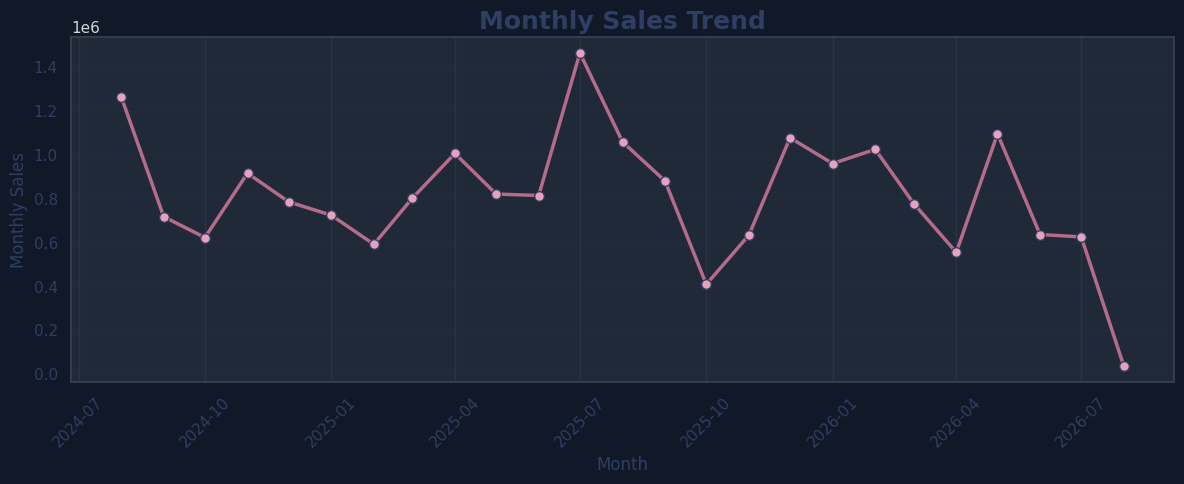

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly["order_date"],
    monthly["sales_amount"],
    marker="o",
    linewidth=2.5,
    color="#B56B8A",
    markerfacecolor="#E8A0BF",
    markeredgecolor="#2F3E63",
    markersize=7
)

plt.title(
    "Monthly Sales Trend",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Month", color="#2F3E63")
plt.ylabel("Monthly Sales", color="#2F3E63")

plt.xticks(rotation=45, color="#2F3E63")
plt.yticks(color="#2F3E63")

plt.grid(
    axis="y",
    alpha=0.15
)

plt.tight_layout()
plt.show()

In [51]:
monthly_promo = (
    sales
    .groupby(sales["order_date"].dt.to_period("M"))
    .agg(
        sales=("sales_amount", "sum"),
        orders=("order_id", "nunique"),
        promotions=("promotion_id", "nunique")
    )
    .reset_index()
)
monthly_promo["order_date"] = monthly_promo["order_date"].dt.to_timestamp()
monthly_promo

,order_date,sales,orders,promotions
0,2024-08-01,1267016.88,30,13
1,2024-09-01,718784.88,22,12
2,2024-10-01,623702.57,17,13
3,2024-11-01,917222.67,23,13
4,2024-12-01,786552.55,18,10
5,2025-01-01,725477.87,14,8
6,2025-02-01,592913.86,18,15
7,2025-03-01,803477.03,21,14
8,2025-04-01,1007392.22,18,11
9,2025-05-01,822228.27,19,10


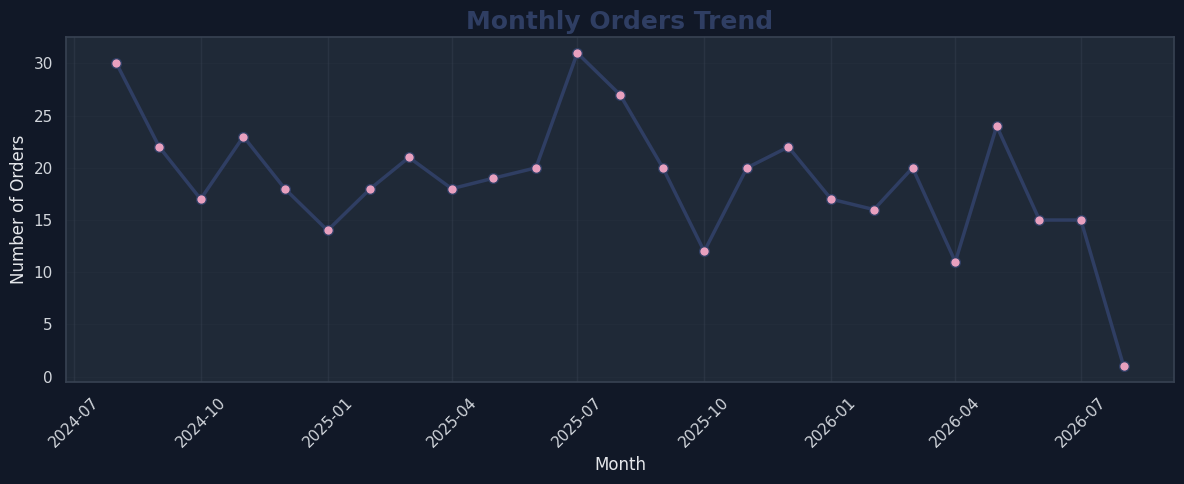

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_promo["order_date"],
    monthly_promo["orders"],
    marker="o",
    linewidth=2.5,
    color="#2F3E63",
    markerfacecolor="#E8A0BF",
    markeredgecolor="#2F3E63",
    markersize=7
)

plt.title("Monthly Orders Trend", fontsize=18, fontweight="bold", color="#2F3E63")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

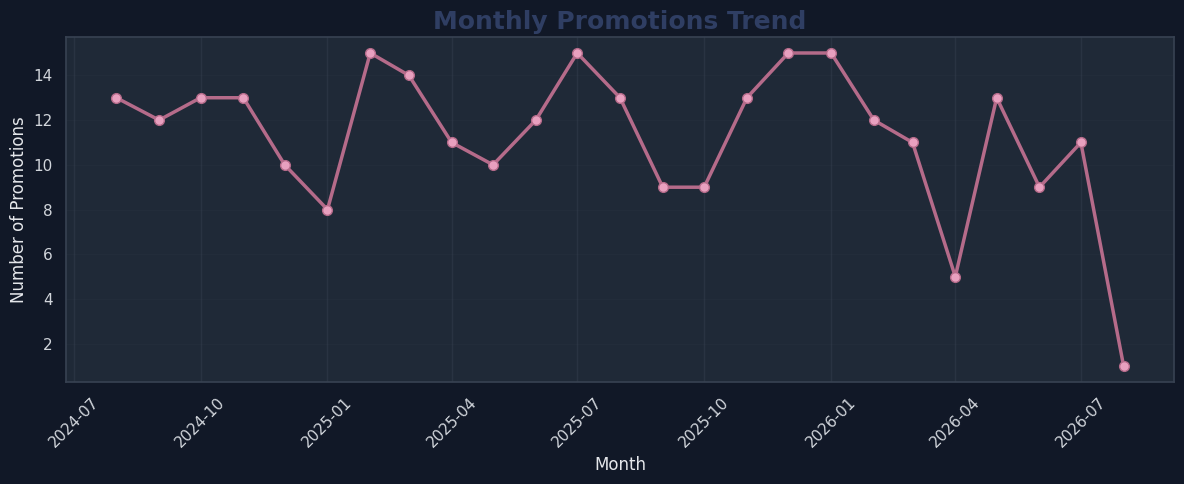

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_promo["order_date"],
    monthly_promo["promotions"],
    marker="o",
    linewidth=2.5,
    color="#B56B8A",
    markerfacecolor="#E8A0BF",
    markeredgecolor="#B56B8A",
    markersize=7
)

plt.title("Monthly Promotions Trend", fontsize=18, fontweight="bold", color="#2F3E63")
plt.xlabel("Month")
plt.ylabel("Number of Promotions")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

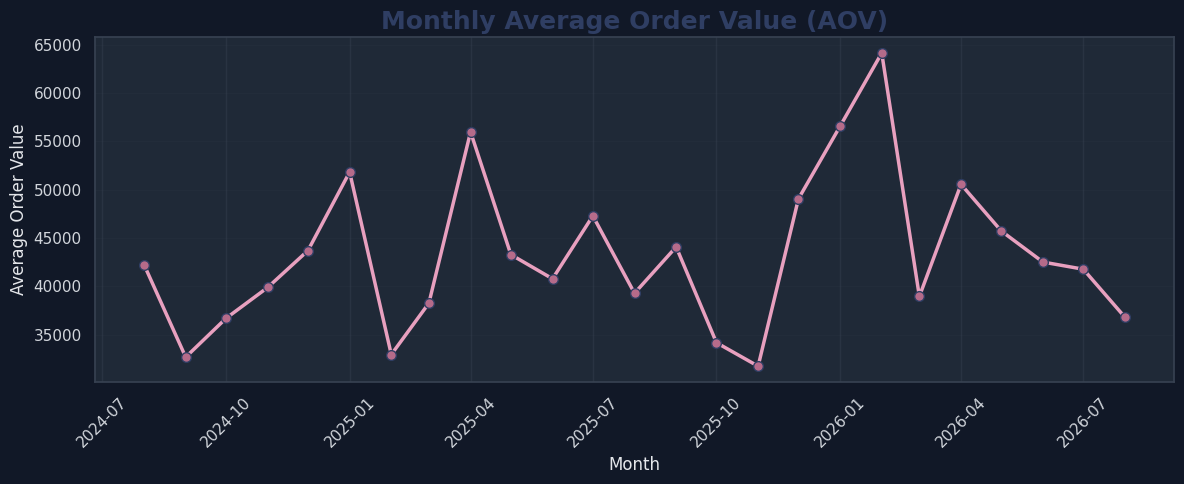

In [54]:
monthly_promo["AOV"] = (
    monthly_promo["sales"] / monthly_promo["orders"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_promo["order_date"],
    monthly_promo["AOV"],
    marker="o",
    linewidth=2.5,
    color="#E8A0BF",
    markerfacecolor="#B56B8A",
    markeredgecolor="#2F3E63",
    markersize=7
)

plt.title(
    "Monthly Average Order Value (AOV)",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

In [55]:
promo_sales = sales.merge(
    promotions[["promotion_id", "promotion_type"]],
    on="promotion_id",
    how="left"
)

In [56]:
promo_sales = promo_sales.dropna(
    subset=["promotion_type"]
)

In [57]:
promo_impact = (
    promo_sales
    .groupby("promotion_type")
    .agg(
        sales=("sales_amount", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

promo_impact

,promotion_type,sales,orders
0,Clearance,3508932.64,80
1,Discount,4739850.20,110
2,Seasonal,4275818.34,91
3,Special Offer,3373184.86,77


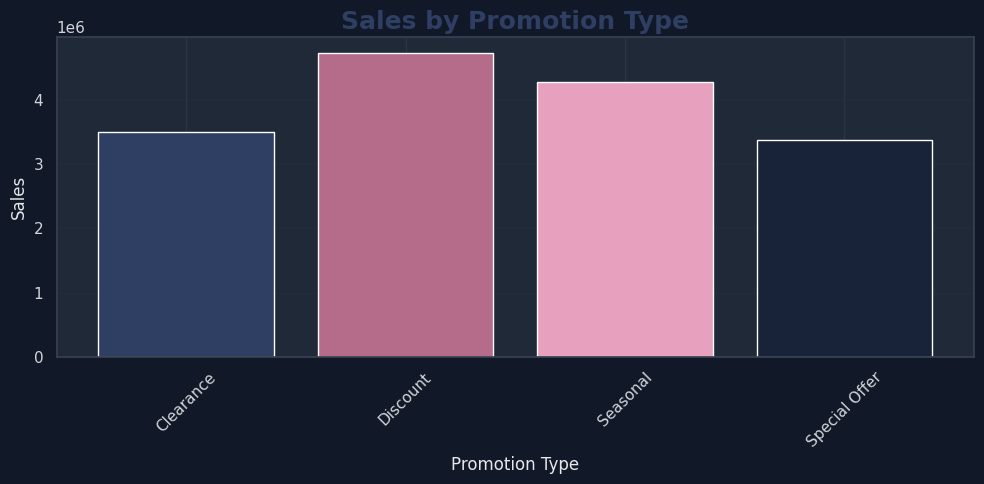

In [58]:
plt.figure(figsize=(10, 5))

colors = ["#2F3E63", "#B56B8A", "#E8A0BF", "#182238"]

plt.bar(
    promo_impact["promotion_type"],
    promo_impact["sales"],
    color=colors[:len(promo_impact)]
)

plt.title(
    "Sales by Promotion Type",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Promotion Type")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

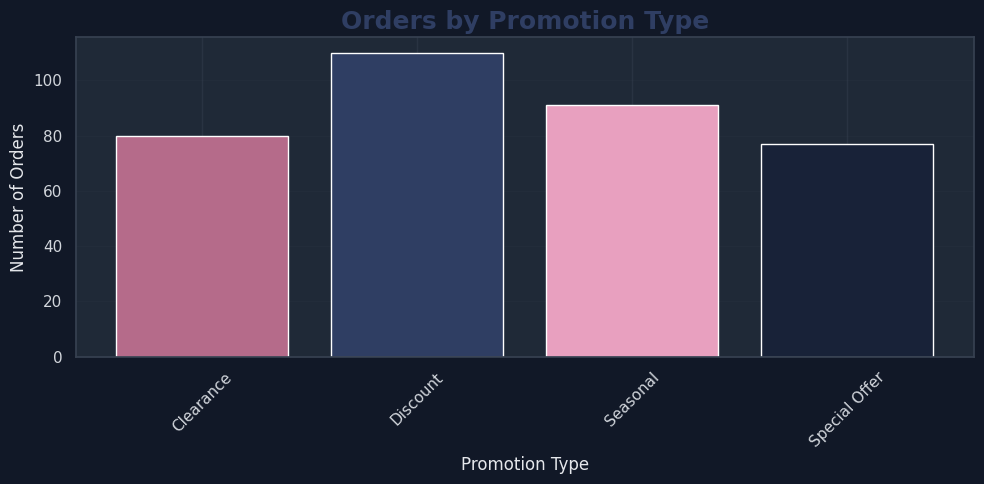

In [59]:
plt.figure(figsize=(10, 5))

colors = ["#B56B8A", "#2F3E63", "#E8A0BF", "#182238"]

plt.bar(
    promo_impact["promotion_type"],
    promo_impact["orders"],
    color=colors[:len(promo_impact)]
)

plt.title(
    "Orders by Promotion Type",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Promotion Type")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

In [60]:
promo_sales["month"] = (
    promo_sales["order_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [61]:
monthly_promo_type = (
    promo_sales
    .dropna(subset=["promotion_type"])
    .groupby(["month", "promotion_type"])
    .agg(
        sales=("sales_amount", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

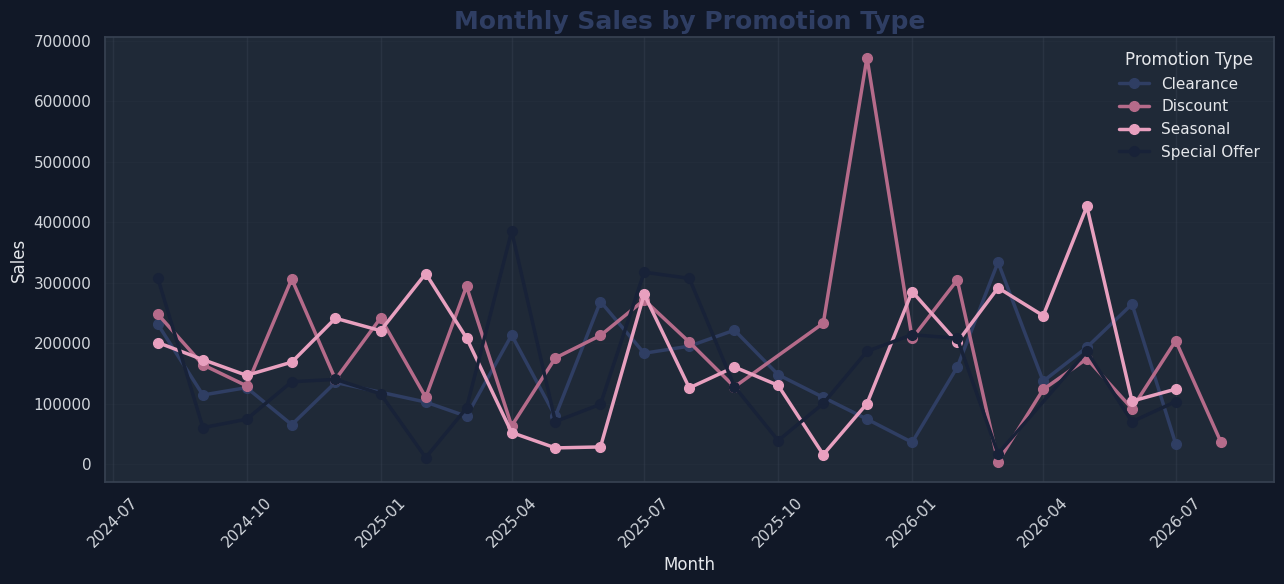

In [62]:
plt.figure(figsize=(13, 6))

colors = [
    "#2F3E63",
    "#B56B8A",
    "#E8A0BF",
    "#182238"
]

for i, promo_type in enumerate(
    monthly_promo_type["promotion_type"].unique()
):

    data = monthly_promo_type[
        monthly_promo_type["promotion_type"] == promo_type
    ]

    plt.plot(
        data["month"],
        data["sales"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        color=colors[i % len(colors)],
        label=promo_type
    )

plt.title(
    "Monthly Sales by Promotion Type",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.15
)

plt.legend(
    title="Promotion Type",
    frameon=False
)

plt.tight_layout()
plt.show()

In [63]:
monthly_promo[
    ["sales", "orders", "promotions"]
].corr()["sales"].sort_values(ascending=False)

sales         1.000000
orders        0.873685
promotions    0.685363
Name: sales, dtype: float64

In [64]:
monthly_promo[
    ["orders", "promotions"]
].corr()

,orders,promotions
orders,1.000000,0.773825
promotions,0.773825,1.000000


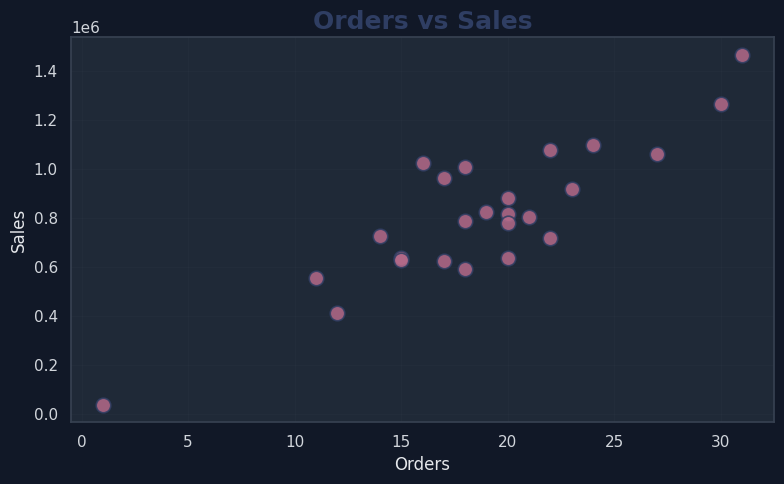

In [65]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_promo["orders"],
    monthly_promo["sales"],
    s=110,
    alpha=0.85,
    color="#B56B8A",
    edgecolors="#2F3E63",
    linewidths=1.2
)

plt.title(
    "Orders vs Sales",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Orders")
plt.ylabel("Sales")

plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

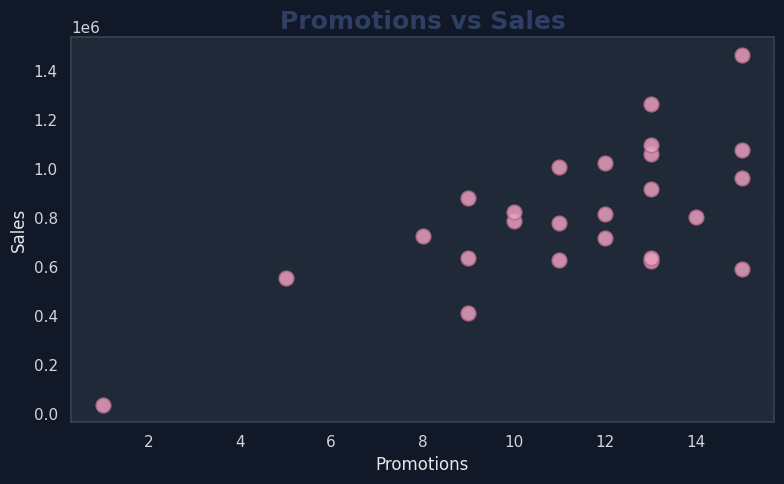

In [66]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_promo["promotions"],
    monthly_promo["sales"],
    s=110,
    alpha=0.85,
    color="#E8A0BF",
    edgecolors="#B56B8A",
    linewidths=1.2
)

plt.title(
    "Promotions vs Sales",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Promotions")
plt.ylabel("Sales")

plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

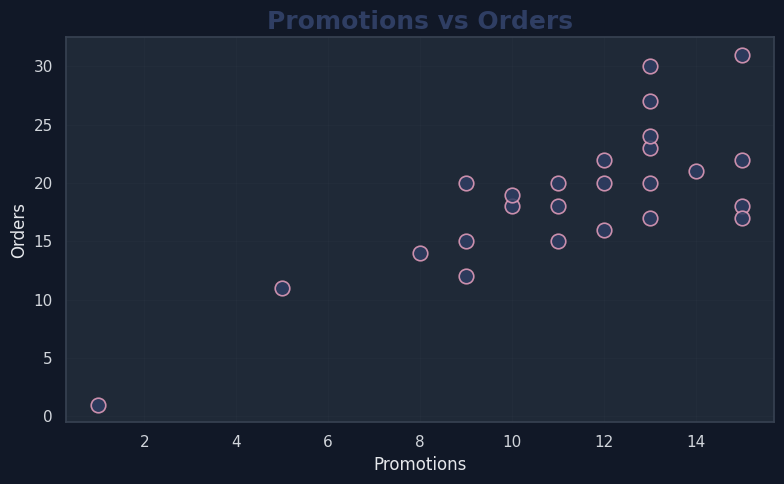

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(
    monthly_promo["promotions"],
    monthly_promo["orders"],
    s=110,
    alpha=0.85,
    color="#2F3E63",
    edgecolors="#E8A0BF",
    linewidths=1.2
)

plt.title(
    "Promotions vs Orders",
    fontsize=18,
    fontweight="bold",
    color="#2F3E63"
)

plt.xlabel("Promotions")
plt.ylabel("Orders")

plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = monthly_promo[["orders"]]
y = monthly_promo["sales"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r = monthly_promo["orders"].corr(monthly_promo["sales"])
r2 = r2_score(y, y_pred)

print(f"Correlation (r): {r:.3f}")
print(f"R²: {r2:.3f}")

Correlation (r): 0.874
R²: 0.763


In [69]:
X = monthly_promo[["promotions"]]
y = monthly_promo["sales"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r = monthly_promo["promotions"].corr(monthly_promo["sales"])
r2 = r2_score(y, y_pred)

print(f"Correlation (r): {r:.3f}")
print(f"R²: {r2:.3f}")

Correlation (r): 0.685
R²: 0.470


In [70]:
X = monthly_promo[["promotions"]]
y = monthly_promo["orders"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r = monthly_promo["promotions"].corr(monthly_promo["orders"])
r2 = r2_score(y, y_pred)

print(f"Correlation (r): {r:.3f}")
print(f"R²: {r2:.3f}")

Correlation (r): 0.774
R²: 0.599


<div style="background-color:#080B1A; border:2px solid #7C3AED; border-radius:15px; padding:25px; color:#FFFFFF;">

<h2 style="color:#FF4FD8; margin-top:0;">
 FINAL BUSINESS INSIGHTS
</h2>

<hr style="border:1px solid #7C3AED;">

<h3 style="color:#C084FC;">
 Sales Performance
</h3>

<p>
Sales fluctuate over time rather than following a clear linear trend.
</p>

<p>
<b style="color:#FF4FD8;">Orders</b> are the strongest factor associated with
Sales 
<b style="color:#FF4FD8;">(r = 0.874, R² = 0.763)</b>,
while Promotions are positively associated with both
<b style="color:#C084FC;">Orders (r = 0.774)</b>
and
<b style="color:#C084FC;">Sales (r = 0.685)</b>.
</p>

<h3 style="color:#C084FC;">
 Customer Insights
</h3>

<p>
RFM segmentation identifies different customer groups based on
<b>Recency, Frequency, and Monetary Value.</b>
</p>

<p>
<b style="color:#FF4FD8;">Champions & Loyal Customers</b>
should be prioritized for retention and upselling, while
<b style="color:#C084FC;">At Risk</b> customers require targeted
win-back campaigns.
</p>

<h3 style="color:#C084FC;">
 Inventory Insights
</h3>

<p>
Products with
<b style="color:#FF4FD8;">High Demand + Low Inventory</b>
represent potential stockout risks.
</p>

<p>
Products with
<b style="color:#C084FC;">Low Demand + High Inventory</b>
may indicate overstock and require inventory optimization.
</p>

<h3 style="color:#C084FC;">
 Machine Learning
</h3>

<p>
Linear Regression provides a baseline for predicting
<b style="color:#FF4FD8;">Sales</b>
using available sales drivers.
Model performance is evaluated using
<b>R², MAE, and RMSE.</b>
</p>

<hr style="border:1px solid #7C3AED;">

<h3 style="color:#FF4FD8;">
 Overall Recommendation
</h3>

<p>
Focus on <b>retaining high-value customers</b>,
recovering <b>at-risk customers</b>,
keeping <b>high-demand products sufficiently stocked</b>,
and using <b>promotions strategically</b> to support order growth.
</p>

</div>